<a href="https://colab.research.google.com/github/biaamarquess/Projeto-Telemetria-Espacial/blob/main/Relat%C3%B3rio_operacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dados de telemetria em CSV**

In [ ]:
dados_csv = """timestamp,temp_interna,temp_externa,integridade,energia_percent,pressao_tanques,modulo1,modulo2,modulo3,modulo4
21/03/2026 08:00:00,22.5,15.2,1,94.5,2.45,1,1,1,1
21/03/2026 08:05:00,23.1,14.8,1,93.8,2.42,1,1,1,1
21/03/2026 08:10:00,23.8,14.5,1,92.9,2.40,1,1,1,1
21/03/2026 08:15:00,24.2,14.2,1,91.7,2.38,1,1,1,1
21/03/2026 08:20:00,24.5,13.8,1,90.3,2.35,1,1,1,1
21/03/2026 08:25:00,24.9,13.5,1,88.9,2.32,1,1,1,1
21/03/2026 08:30:00,25.3,13.2,1,87.2,2.30,1,1,1,1
21/03/2026 08:35:00,25.8,12.9,1,85.5,2.28,1,1,1,1
21/03/2026 08:40:00,32.5,12.5,1,84.0,2.25,1,1,1,1
21/03/2026 08:45:00,34.2,12.2,1,82.1,2.22,1,1,1,1
21/03/2026 08:50:00,36.0,12.0,1,80.0,2.20,1,1,1,1
21/03/2026 08:55:00,37.5,11.8,0,78.5,1.95,1,1,1,0
21/03/2026 09:00:00,38.2,11.5,0,75.0,1.75,1,1,0,0
21/03/2026 09:05:00,39.0,11.2,0,72.0,1.60,1,0,0,0
21/03/2026 09:10:00,40.5,11.0,0,68.0,1.50,0,0,0,0"""

In [ ]:
def exibir_tabela():
    linhas = dados_csv.strip().split('\n')
    cabecalho = linhas[0].split(',')
    dados = [linha.split(',') for linha in linhas[1:]]

    print("\n" + "="*110)
    print("📡 DADOS DE TELEMETRIA - SIMULAÇÃO")
    print("="*110)

    # Cabeçalho
    print(f"{cabecalho[0]:<20} {cabecalho[1]:<12} {cabecalho[2]:<12} {cabecalho[3]:<10} {cabecalho[4]:<12} {cabecalho[5]:<12} {cabecalho[6]:<6} {cabecalho[7]:<6} {cabecalho[8]:<6} {cabecalho[9]:<6}")
    print("-"*110)

    # Dados
    for linha in dados:
        print(f"{linha[0]:<20} {linha[1]:<12} {linha[2]:<12} {linha[3]:<10} {linha[4]:<12} {linha[5]:<12} {linha[6]:<6} {linha[7]:<6} {linha[8]:<6} {linha[9]:<6}")

exibir_tabela()


📡 DADOS DE TELEMETRIA - SIMULAÇÃO
timestamp            temp_interna temp_externa integridade energia_percent pressao_tanques modulo1 modulo2 modulo3 modulo4
--------------------------------------------------------------------------------------------------------------
21/03/2026 08:00:00  22.5         15.2         1          94.5         2.45         1      1      1      1     
21/03/2026 08:05:00  23.1         14.8         1          93.8         2.42         1      1      1      1     
21/03/2026 08:10:00  23.8         14.5         1          92.9         2.40         1      1      1      1     
21/03/2026 08:15:00  24.2         14.2         1          91.7         2.38         1      1      1      1     
21/03/2026 08:20:00  24.5         13.8         1          90.3         2.35         1      1      1      1     
21/03/2026 08:25:00  24.9         13.5         1          88.9         2.32         1      1      1      1     
21/03/2026 08:30:00  25.3         13.2         1          8



---



# **Algoritmo de verificação- Fluxograma**

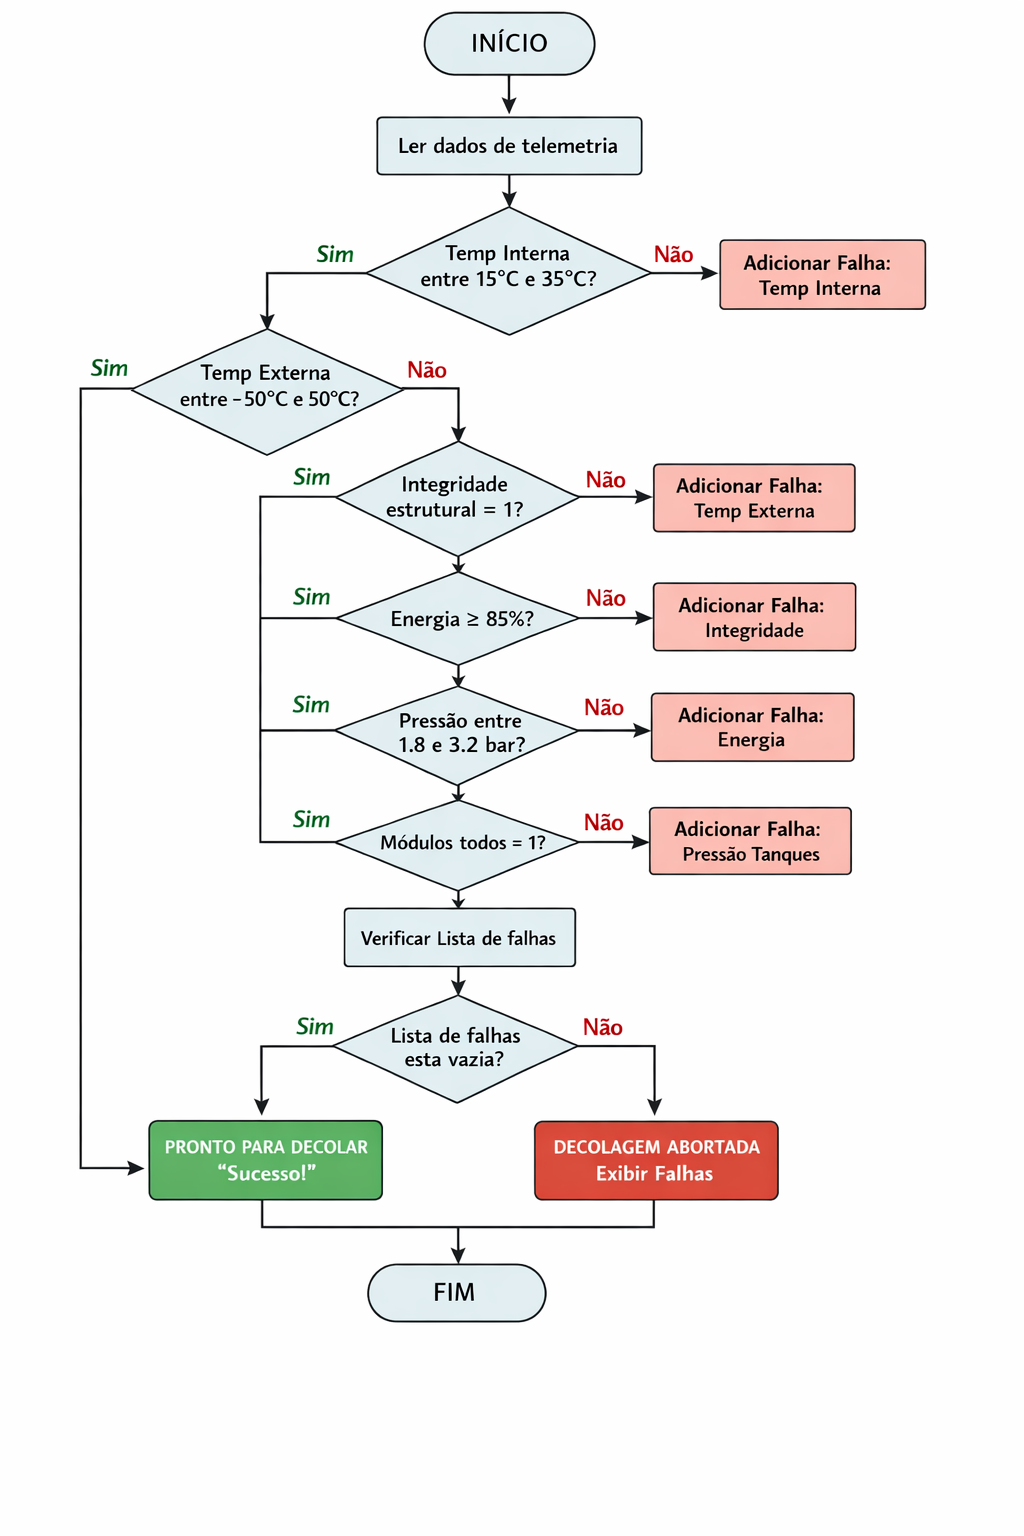



---



# **Script em Python**

In [ ]:
import random
from datetime import datetime

# CLASSE TELEMETRIA
class Telemetria:

    def __init__(self, dados):
        self.temp_interna = dados.get('temp_interna', 0.0)
        self.temp_externa = dados.get('temp_externa', 0.0)
        self.integridade = dados.get('integridade', 0)
        self.energia_percent = dados.get('energia_percent', 0.0)
        self.pressao_tanques = dados.get('pressao_tanques', 0.0)
        self.modulos = dados.get('modulos', [0, 0, 0, 0])
        self.timestamp = dados.get('timestamp', datetime.now().strftime("%d/%m/%Y %H:%M:%S"))

    def exibir_dados(self):
        print("\n" + "="*50)
        print(f"TELEMETRIA - {self.timestamp}")
        print("="*50)
        print(f"Temperatura interna: {self.temp_interna:.1f} °C")
        print(f"Temperatura externa: {self.temp_externa:.1f} °C")
        print(f"Integridade estrutural: {self.integridade}")
        print(f"Energia: {self.energia_percent:.1f}%")
        print(f"Pressão dos tanques: {self.pressao_tanques:.2f} bar")
        modulos_ok = sum(self.modulos)
        print(f"Módulos críticos: {modulos_ok}/4 OK")
        print("="*50)

    def verificar_telemetria(self):

        falhas = []

        LIMITES = {
            'temp_interna': (15, 35),      # 15°C a 35°C
            'temp_externa': (-50, 50),     # -50°C a 50°C
            'pressao_tanques': (1.8, 3.2), # 1.8 a 3.2 bar
            'energia_minima': 85.0,        # mínimo 85%
            'integridade_ok': 1
        }

        # Verificações
        if not (LIMITES['temp_interna'][0] <= self.temp_interna <= LIMITES['temp_interna'][1]):
            falhas.append(f"Temperatura interna fora da faixa ({self.temp_interna:.1f}°C). Faixa: {LIMITES['temp_interna'][0]}-{LIMITES['temp_interna'][1]}°C")

        if not (LIMITES['temp_externa'][0] <= self.temp_externa <= LIMITES['temp_externa'][1]):
            falhas.append(f"Temperatura externa fora da faixa ({self.temp_externa:.1f}°C). Faixa: {LIMITES['temp_externa'][0]}-{LIMITES['temp_externa'][1]}°C")

        if self.integridade != LIMITES['integridade_ok']:
            falhas.append(f"Falha na integridade estrutural (status: {self.integridade})")

        if self.energia_percent < LIMITES['energia_minima']:
            falhas.append(f"Energia insuficiente ({self.energia_percent:.1f}%). Mínimo: {LIMITES['energia_minima']}%")

        if not (LIMITES['pressao_tanques'][0] <= self.pressao_tanques <= LIMITES['pressao_tanques'][1]):
            falhas.append(f"Pressão dos tanques fora da faixa ({self.pressao_tanques:.2f} bar). Faixa: {LIMITES['pressao_tanques'][0]}-{LIMITES['pressao_tanques'][1]} bar")

        # Verificar módulos
        modulos_falhos = [i+1 for i, status in enumerate(self.modulos) if status != 1]
        if modulos_falhos:
            falhas.append(f"Módulos com falha: {modulos_falhos}")

        pronto = len(falhas) == 0
        return pronto, falhas

    def executar_verificacao(self):

        self.exibir_dados()

        pronto, falhas = self.verificar_telemetria()

        print("\nVERIFICAÇÃO PRÉ-LANÇAMENTO")
        print("-" * 30)

        if pronto:
            print("RESULTADO: PRONTO PARA DECOLAR")
            print("Todos os sistemas estão OK!")
        else:
            print("RESULTADO: DECOLAGEM ABORTADA")
            print("Falhas identificadas:")
            for falha in falhas:
                print(f"   • {falha}")

        return pronto

    def analise_energetica(self):

        capacidade_total = 150.0  # 150 kWh
        consumo_decolagem = 350.0  # 350 kW
        perdas = 8.5  # 8.5%

        energia_disponivel = capacidade_total * (self.energia_percent / 100)
        energia_util = energia_disponivel * (1 - perdas / 100)
        consumo_decolagem_total = consumo_decolagem * (5/60)  # 5 minutos em horas

        print("\n" + "="*50)
        print("ANÁLISE ENERGÉTICA")
        print("="*50)
        print(f"Capacidade total: {capacidade_total} kWh")
        print(f"Carga atual: {self.energia_percent:.1f}%")
        print(f"Energia disponível: {energia_disponivel:.2f} kWh")
        print(f"Perdas: {perdas}%")
        print(f"Energia útil: {energia_util:.2f} kWh")
        print(f"Consumo na decolagem: {consumo_decolagem} kW")
        print(f"Consumo para 5min: {consumo_decolagem_total:.2f} kWh")
        print("-" * 50)

        if energia_util >= consumo_decolagem_total * 1.1:
            print("Energia suficiente para decolagem com margem de segurança")
        else:
            print("ALERTA: Energia insuficiente para decolagem")


# FUNÇÕES AUXILIARES
def ler_dados_manualmente():
    """Permite ao usuário digitar os dados manualmente"""
    print("\nDIGITE OS DADOS DE TELEMETRIA:")
    print("-" * 40)

    dados = {}

    dados['temp_interna'] = float(input("Temperatura interna (°C): "))
    dados['temp_externa'] = float(input("Temperatura externa (°C): "))
    dados['integridade'] = int(input("Integridade estrutural (1=OK, 0=Falha): "))
    dados['energia_percent'] = float(input("Nível de energia (%): "))
    dados['pressao_tanques'] = float(input("Pressão dos tanques (bar): "))

    print("Status dos 4 módulos críticos (1=OK, 0=Falha):")
    modulos = []
    for i in range(4):
        status = int(input(f"  Módulo {i+1}: "))
        modulos.append(status)
    dados['modulos'] = modulos

    dados['timestamp'] = datetime.now().strftime("%d/%m/%Y %H:%M:%S")

    return dados

def gerar_dados_simulados(pronto=True):

    if pronto:
        # Dados dentro das faixas seguras
        dados = {
            'temp_interna': random.uniform(18, 28),
            'temp_externa': random.uniform(-30, 30),
            'integridade': 1,
            'energia_percent': random.uniform(88, 98),
            'pressao_tanques': random.uniform(2.0, 2.8),
            'modulos': [1, 1, 1, 1],
            'timestamp': datetime.now().strftime("%d/%m/%Y %H:%M:%S")
        }
    else:
        # Dados com falhas aleatórias
        dados = {
            'temp_interna': random.choice([random.uniform(10, 14), random.uniform(36, 45)]),
            'temp_externa': random.choice([random.uniform(-60, -51), random.uniform(51, 70)]),
            'integridade': random.choice([0, 1]),
            'energia_percent': random.uniform(50, 84),
            'pressao_tanques': random.choice([random.uniform(1.0, 1.7), random.uniform(3.3, 4.0)]),
            'modulos': [random.choice([0, 1]) for _ in range(4)],
            'timestamp': datetime.now().strftime("%d/%m/%Y %H:%M:%S")
        }

    return dados

def menu():
    """Exibe o menu principal"""
    print("\n" + "="*60)
    print("SISTEMA DE VERIFICAÇÃO DE TELEMETRIA")
    print("="*60)
    print("1 - Teste com dados simulados (Tudo OK)")
    print("2 - Teste com dados simulados (Com falhas)")
    print("3 - Inserir dados manualmente")
    print("4 - Sair")
    print("-"*60)

    return input("Escolha uma opção (1-4): ")

# FUNÇÃO PRINCIPAL
def main():

    while True:
        opcao = menu()

        if opcao == "1":
            print("\nSIMULANDO DADOS - CENÁRIO NOMINAL (TUDO OK)")
            dados = gerar_dados_simulados(pronto=True)
            telemetria = Telemetria(dados)
            telemetria.executar_verificacao()
            telemetria.analise_energetica()

            input("\nPressione ENTER para continuar...")

        elif opcao == "2":
            print("\nSIMULANDO DADOS - CENÁRIO COM FALHAS")
            dados = gerar_dados_simulados(pronto=False)
            telemetria = Telemetria(dados)
            telemetria.executar_verificacao()
            telemetria.analise_energetica()

            input("\nPressione ENTER para continuar...")

        elif opcao == "3":
            dados = ler_dados_manualmente()
            telemetria = Telemetria(dados)
            telemetria.executar_verificacao()
            telemetria.analise_energetica()

            input("\nPressione ENTER para continuar...")

        elif opcao == "4":
            print("\nEncerrando o programa...")
            break

        else:
            print("\nOpção inválida! Tente novamente.")

# Executar o programa
if __name__ == "__main__":
    main()



---



# **Análise energética**

In [ ]:
def analise_energetica(energia_percent):

    capacidade_total = 150.0  # 150 kWh
    consumo_decolagem = 350.0  # 350 kW
    perdas = 8.5  # 8.5%

    energia_disponivel = capacidade_total * (energia_percent / 100)
    energia_util = energia_disponivel * (1 - perdas / 100)
    consumo_decolagem_total = consumo_decolagem * (5/60)  # 5 minutos em horas
    autonomia_minutos = (energia_util / consumo_decolagem) * 60

    print("\n" + "="*50)
    print("ANÁLISE ENERGÉTICA")
    print("="*50)
    print(f"Capacidade total: {capacidade_total} kWh")
    print(f"Carga atual: {energia_percent:.1f}%")
    print(f"Energia disponível: {energia_disponivel:.2f} kWh")
    print(f"Perdas estimadas: {perdas}%")
    print(f"Energia útil: {energia_util:.2f} kWh")
    print(f"Consumo na decolagem: {consumo_decolagem} kW")
    print(f"Autonomia estimada: {autonomia_minutos:.0f} minutos")
    print(f"Consumo para 5min decolagem: {consumo_decolagem_total:.2f} kWh")
    print("-" * 50)

    if energia_util >= consumo_decolagem_total * 1.1:
        print("Energia suficiente para decolagem com margem de segurança")
        return True
    else:
        deficit = (consumo_decolagem_total * 1.1) - energia_util
        print(f"ALERTA: Energia insuficiente para decolagem")
        print(f"   Déficit de energia: {deficit:.2f} kWh")
        return False

print("TESTE COM 94% DE ENERGIA")
analise_energetica(94.5)

print("\n" + "-"*50)
print("TESTE COM 72% DE ENERGIA")
analise_energetica(72.0)

TESTE COM 94% DE ENERGIA

ANÁLISE ENERGÉTICA
Capacidade total: 150.0 kWh
Carga atual: 94.5%
Energia disponível: 141.75 kWh
Perdas estimadas: 8.5%
Energia útil: 129.70 kWh
Consumo na decolagem: 350.0 kW
Autonomia estimada: 22 minutos
Consumo para 5min decolagem: 29.17 kWh
--------------------------------------------------
Energia suficiente para decolagem com margem de segurança

--------------------------------------------------
TESTE COM 72% DE ENERGIA

ANÁLISE ENERGÉTICA
Capacidade total: 150.0 kWh
Carga atual: 72.0%
Energia disponível: 108.00 kWh
Perdas estimadas: 8.5%
Energia útil: 98.82 kWh
Consumo na decolagem: 350.0 kW
Autonomia estimada: 17 minutos
Consumo para 5min decolagem: 29.17 kWh
--------------------------------------------------
Energia suficiente para decolagem com margem de segurança


True



---



# **Análise assistida por IA**

**Classificação dos Dados:**

Os dados de telemetria podem ser classificados em três tipos:

Dados quantitativos (contínuos):
Temperatura interna, temperatura externa, nível de energia e pressão dos tanques.

→ Representam medições numéricas e permitem análise por faixa de valores.
Dados categóricos (binários):
Integridade estrutural e status dos módulos (0 = falha, 1 = OK).

→ Indicam o estado de funcionamento dos sistemas.
Dados temporais:
Timestamp.

→ Registra o momento da coleta, permitindo análise ao longo do tempo.

**Identificação de Possíveis Anomalias:**

O sistema identifica anomalias quando os dados estão fora das faixas seguras:

Temperatura interna fora de 15°C a 35°C

Temperatura externa fora de -50°C a 50°C

Pressão dos tanques fora de 1.8 a 3.2 bar

Energia abaixo de 85%

Integridade estrutural com falha

Módulos críticos com falha

**Possíveis melhorias:**

Detectar inconsistências entre sensores (ex: temperatura interna alta e externa muito baixa)
Analisar combinações de risco (ex: baixa energia + baixa pressão)
Monitorar variações ao longo do tempo (tendências)

**Sugestões de Risco:**

Os riscos podem ser classificados em níveis:

Risco crítico (abortar decolagem):
Falha na integridade, energia insuficiente, pressão fora da faixa ou múltiplos módulos com falha.

Risco moderado:
Valores próximos dos limites ou falha em apenas um módulo.

Risco potencial:
Pequenas falhas combinadas, oscilações nos dados ou inconsistências entre sensores.

Sugestão: implementar níveis de alerta (OK, ALERTA, CRÍTICO) para melhorar a tomada de decisão.



---



# **Reflexão crítica**

**Ética e responsabilidade**

O desenvolvimento de sistemas críticos exige responsabilidade, pois erros podem causar grandes consequências. É essencial garantir dados confiáveis, segurança e decisões éticas, priorizando sempre a vida e a integridade dos sistemas.

**Impacto social da exploração espacial**

A exploração espacial gera avanços tecnológicos importantes, mas também levanta questões sobre o uso de recursos. É necessário equilibrar investimentos, garantindo benefícios para toda a sociedade.

**Sustentabilidade tecnológica**

Tecnologias devem ser desenvolvidas com foco na eficiência e redução de impactos ambientais. Otimizar o consumo de energia e adotar práticas sustentáveis é fundamental para um futuro mais responsável.



---



# **Resultado no terminal**

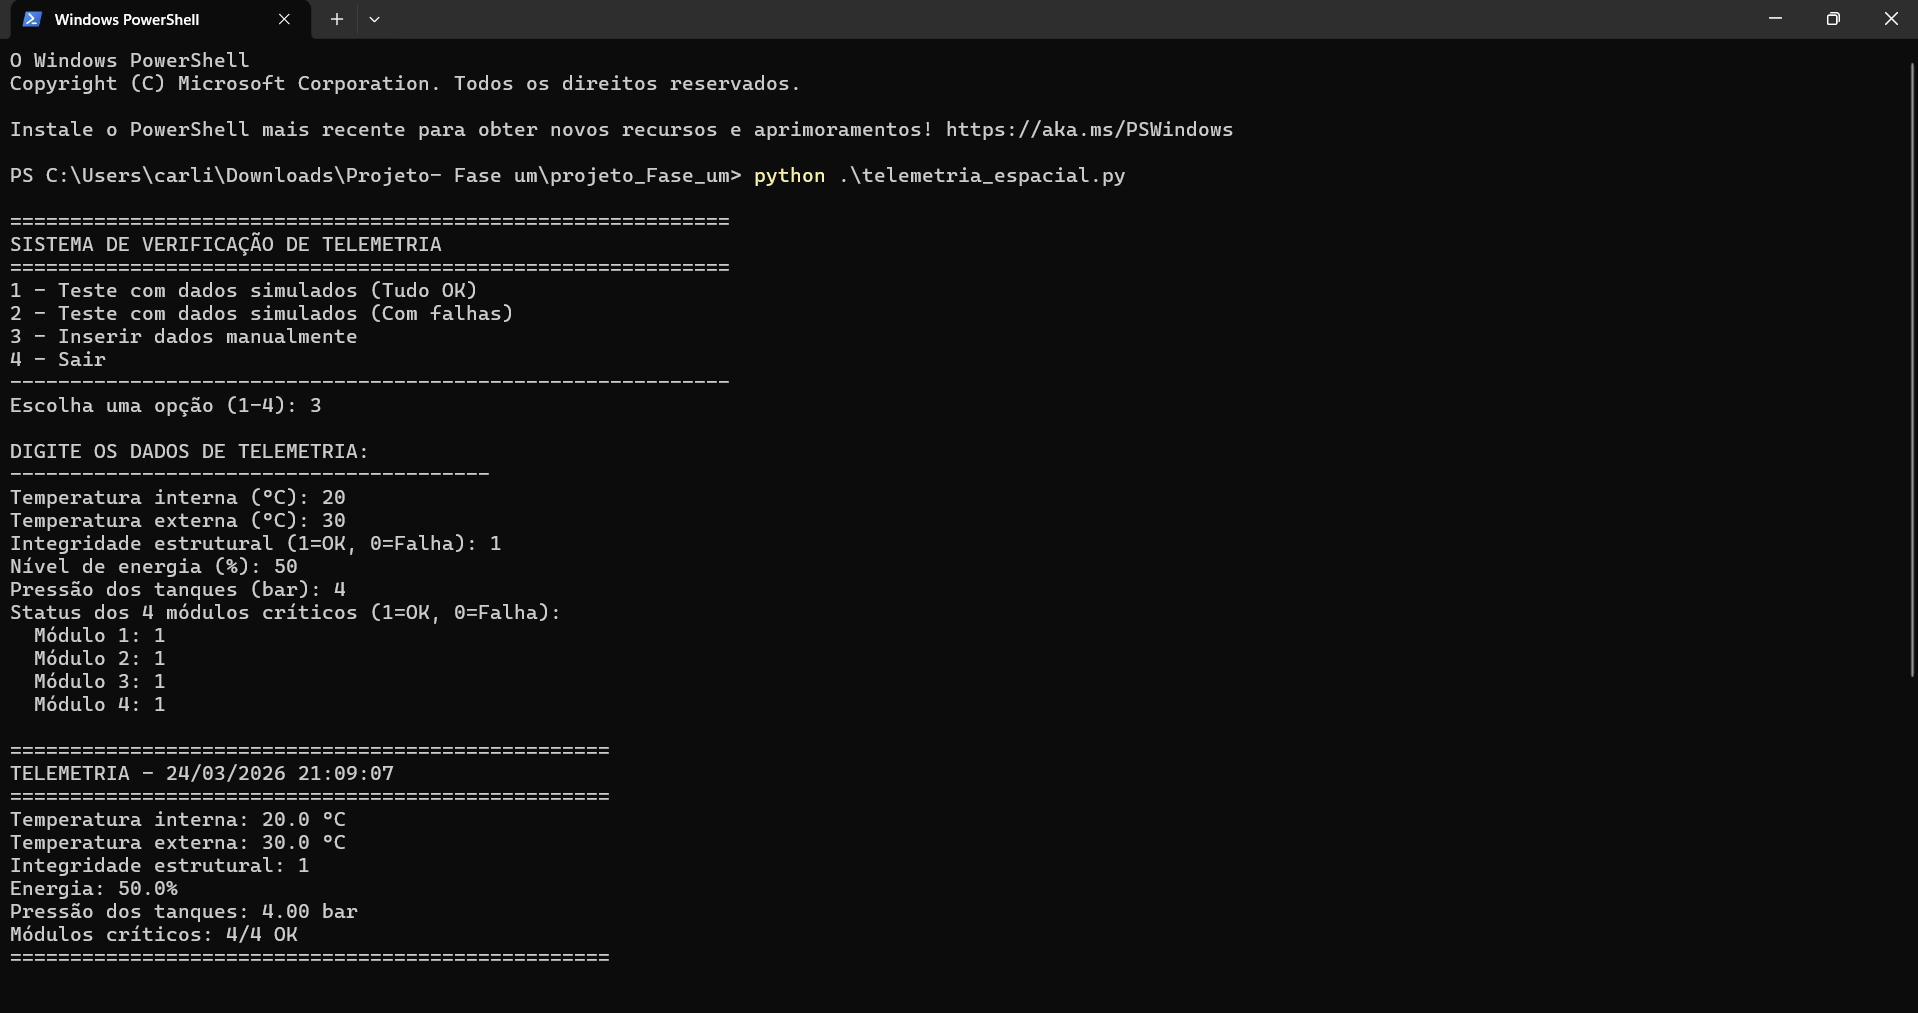

.

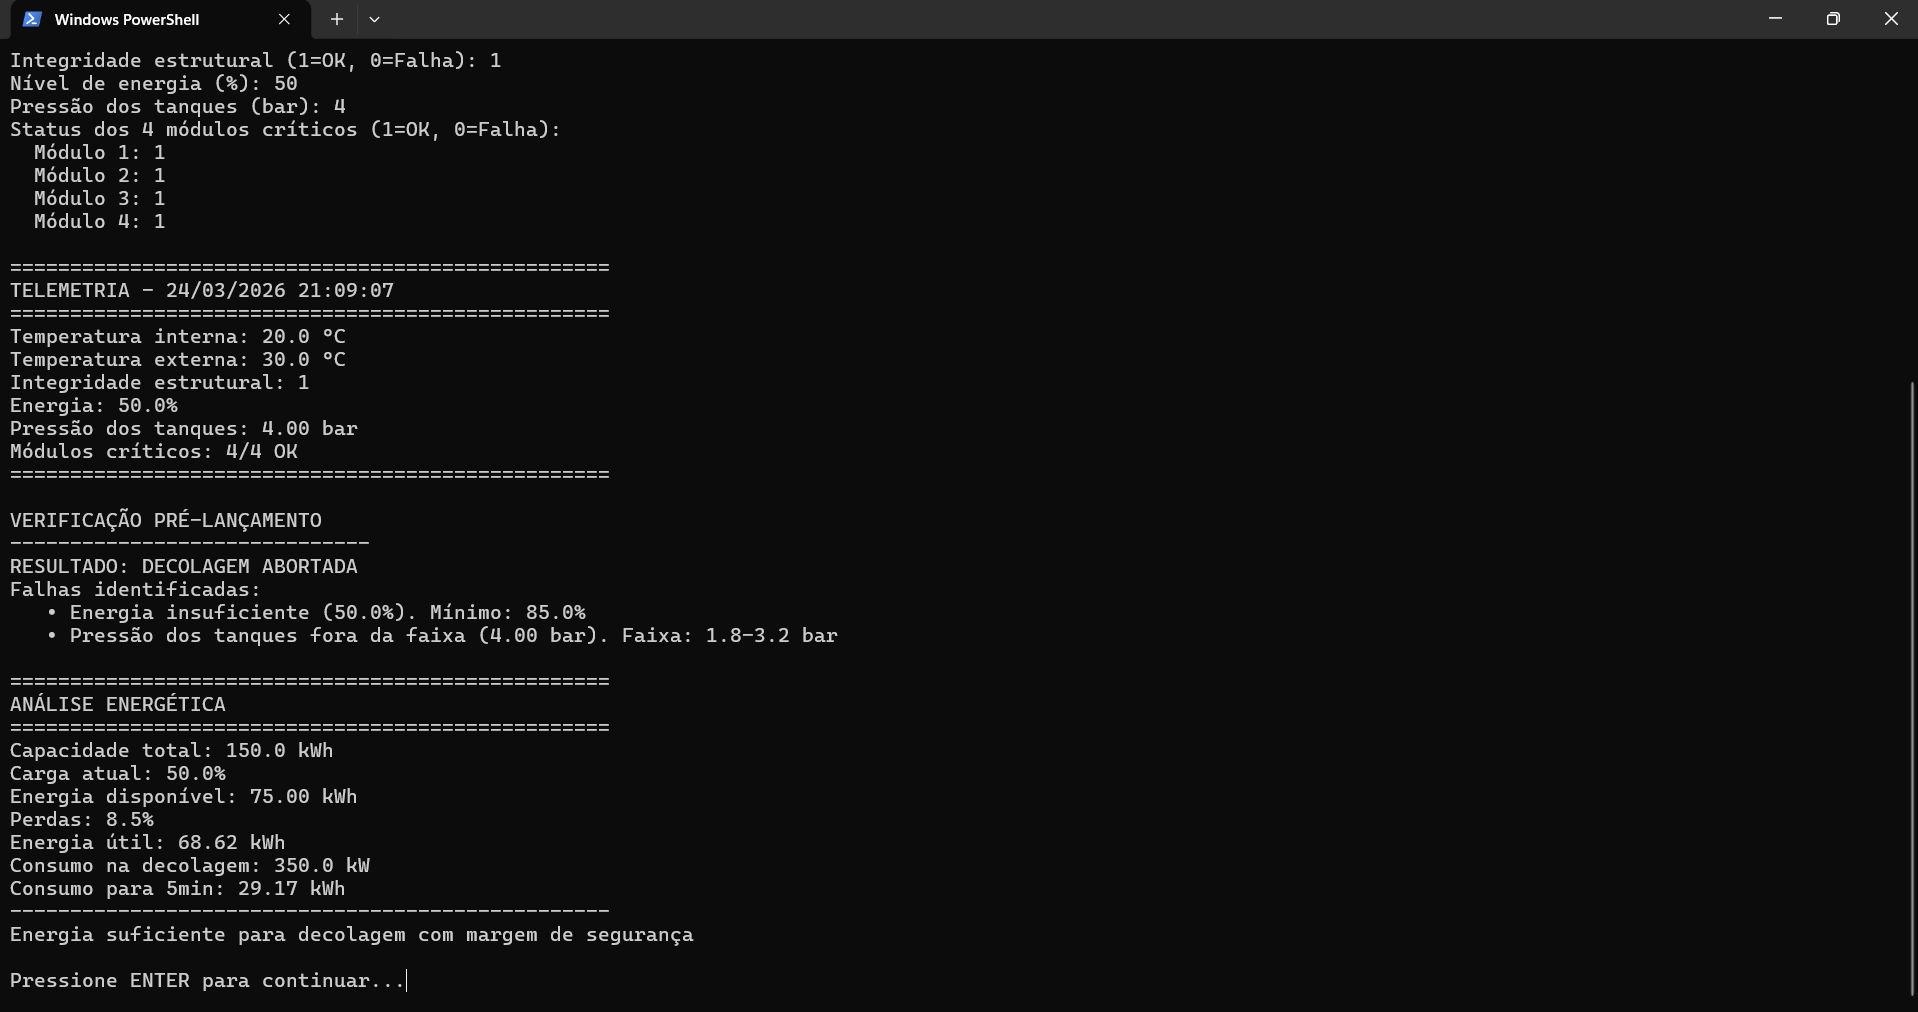

.

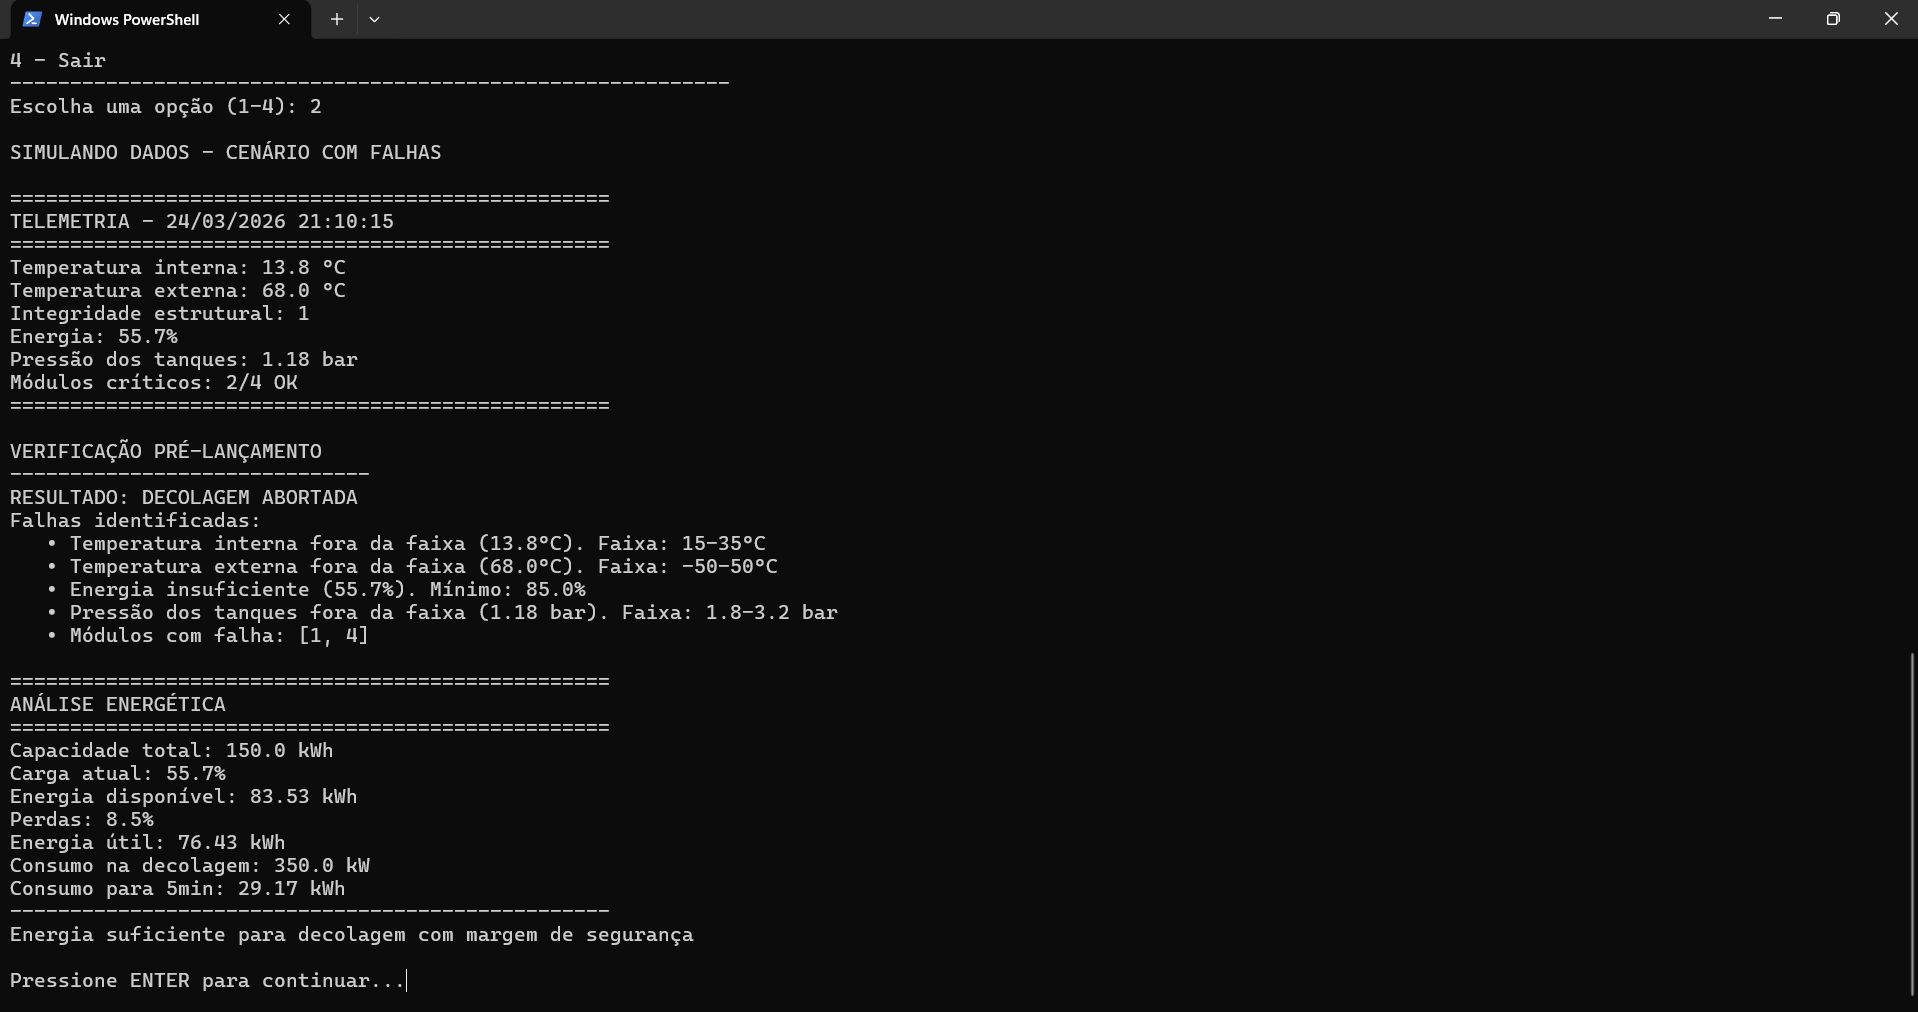

.

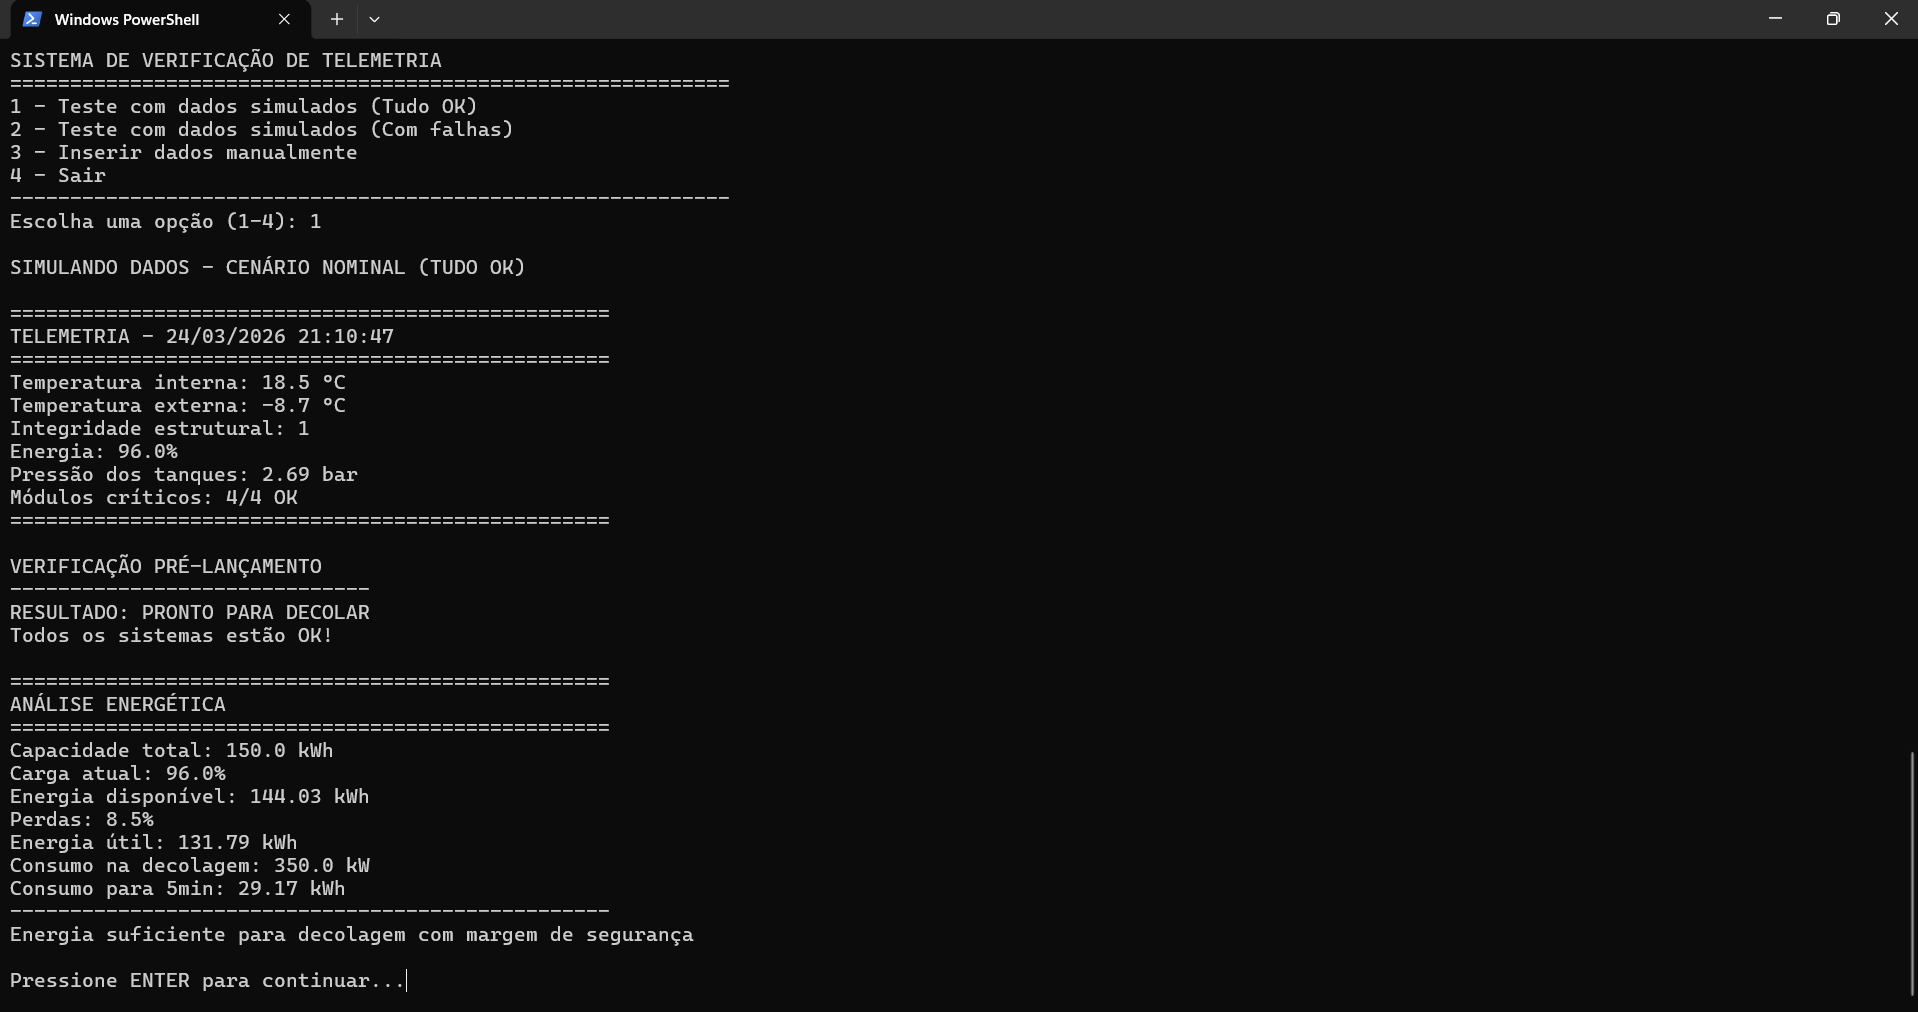



---



# **Link GithHub**

Este é o link do meu GitHub para acessar este projeto, onde você pode visualizar o código, a estrutura e todos os detalhes do desenvolvimento.

https://github.com/biaamarquess/Projeto-Telemetria-Espacial



---

